<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%206/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 — Convolutions From Scratch: How Networks See

**Goal:** Build the convolution operation by hand and watch a simple 3×3 grid of numbers extract real structure — edges — from an image.

Until now, our networks flattened each image into a list of 784 numbers, throwing away the fact that neighboring pixels are related. **Convolutions keep the 2D structure.** A small filter (kernel) slides across the image, and at each position computes a dot product that answers: *"how much does this patch look like the pattern this kernel detects?"*

### Why convolutions beat dense layers for images

| Property | What it means |
|---|---|
| **Parameter sharing** | one small kernel (9 numbers) is reused across the whole image — vs. 600,000+ weights for a dense layer |
| **Locality** | each output looks only at a small neighborhood, respecting that nearby pixels relate |
| **Translation invariance** | an edge is detected wherever it appears, using the same kernel |

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

%matplotlib inline

In [2]:
# Load MNIST — we'll borrow a single digit image to run convolutions on
transform = transforms.Compose([transforms.ToTensor()])

train = torchvision.datasets.MNIST(root='./data', train=True,  transform=transform, download=True)
test  = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.45MB/s]


---
## 1. The Convolution Operation

The core loop: slide the kernel over every valid position, and at each one grab the patch of image beneath it, multiply element-wise with the kernel, and sum. That single sum is one output pixel.

**Output size (stride 1, no padding):** for an $N{\times}N$ image and $K{\times}K$ kernel, the output is $(N-K+1) \times (N-K+1)$ — the number of positions where the kernel fully fits.

The key line is `out[i,j] = np.sum(patch * kernel)`: `patch * kernel` multiplies the overlapping cells (both $K{\times}K$), and `np.sum` collapses those products into the single output value — the dot product at that position.

In [3]:
def convolution(image, kernel):
  # Dimensions
  img_h, img_w = image.shape
  ker_h, ker_w = kernel.shape

  # Output size for stride 1, no padding: (N - K + 1)
  out_h = img_h - ker_h + 1
  out_w = img_w - ker_w + 1

  out = np.zeros((out_h, out_w))

  # Slide the kernel through every possible position
  for i in range(out_h):
    for j in range(out_w):
      # 1. grab the current patch of the image under the kernel
      patch = image[i:i+ker_h, j:j+ker_w]

      # 2. element-wise multiply with kernel, then sum -> one output value
      out[i, j] = np.sum(patch * kernel)

  return out

### Sanity check with an all-ones kernel

With a kernel of all 1s, each output is simply the **sum of the 3×3 patch** beneath it — easy to verify by hand. The top-left output should be $1{+}2{+}3{+}4{+}5{+}6{+}7{+}8{+}9 = 45$.

In [4]:
image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 3],
    [1, 0, 1, 4, 5],
    [2, 3, 4, 0, 1],
], dtype=float)

kernel = np.ones((3, 3))

result = convolution(image, kernel)
print("Output shape:", result.shape, "(expected 3x3)")
print(result)

Output shape: (3, 3) (expected 3x3)
[[45. 36. 25.]
 [41. 36. 31.]
 [35. 31. 29.]]


In [5]:
# Verify the bottom-right output by hand: sum of the bottom-right 3x3 patch
print("By hand:", 9 + 2 + 3 + 1 + 4 + 5 + 4 + 0 + 1)
print("From conv:", result[-1, -1])

By hand: 29
From conv: 29.0


---
## 2. Edge Detection — Seeing a Kernel Work

This is the payoff. A hand-designed kernel can detect **edges**. The vertical-edge kernel

$$\begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}$$

subtracts the left column from the right column of each patch. Where the image is flat (left ≈ right), the output is ~0. Where there's a **vertical edge** (a sharp left-to-right change), the output is large. The horizontal-edge kernel is the same idea rotated 90°.

A trained CNN *learns* kernels like these automatically — this is exactly what its first layer discovers.

Image shape: (28, 28)


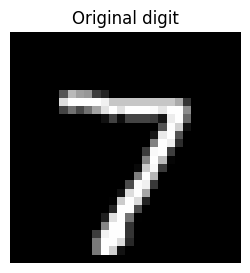

In [6]:
# Grab one MNIST digit as a plain NumPy array
image = test.data[0].numpy().astype(float)
print("Image shape:", image.shape)

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap='gray')
plt.title('Original digit')
plt.axis('off')
plt.show()

In [7]:
# Vertical and horizontal edge-detector kernels
vertical_kernel = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])

horizontal_kernel = np.array([[-1, -1, -1],
                              [ 0,  0,  0],
                              [ 1,  1,  1]])

vertical_edges   = convolution(image, vertical_kernel)
horizontal_edges = convolution(image, horizontal_kernel)

print("Edge map shape:", vertical_edges.shape, "(28 - 3 + 1 = 26)")

Edge map shape: (26, 26) (28 - 3 + 1 = 26)


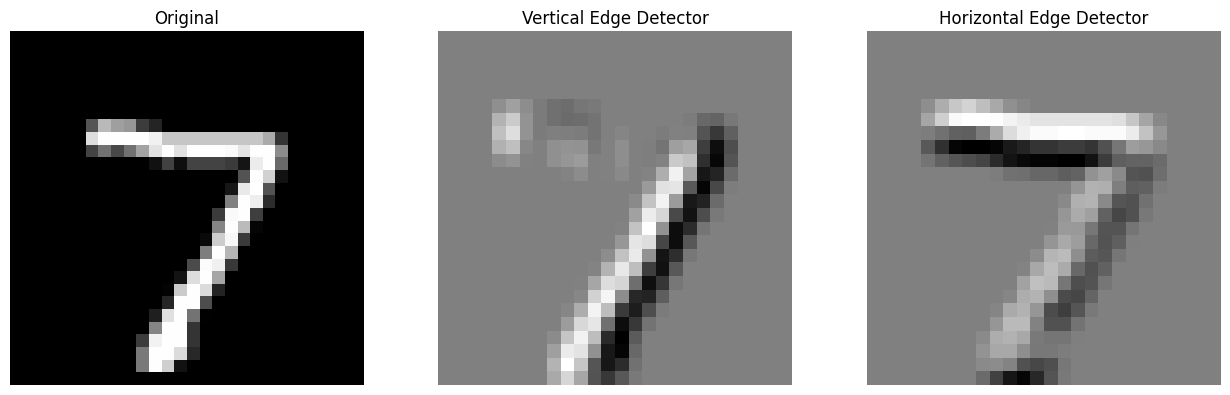

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(vertical_edges, cmap='gray')
axes[1].set_title('Vertical Edge Detector')
axes[1].axis('off')

axes[2].imshow(horizontal_edges, cmap='gray')
axes[2].set_title('Horizontal Edge Detector')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Look at the difference between the two edge maps.** The vertical detector highlights the left and right sides of strokes; the horizontal detector highlights the tops and bottoms. Two tiny 3×3 grids, no training, pulling out orientation-specific structure. Stack thousands of *learned* kernels across many layers and you get a system that recognizes objects.

---
## 3. Stride and Padding

Two knobs that control how the kernel moves and how the output is sized:

- **Stride (S):** how many pixels the kernel jumps each step. Stride 2 skips every other position, roughly halving the output — a cheap way to downsample.
- **Padding (P):** a border of zeros added around the image before convolving. Padding lets outputs stay the same size as the input (otherwise convolution always shrinks them).

### The output-size formula
$$\text{out} = \frac{N - K + 2P}{S} + 1$$

The critical implementation trick is in the loop: the loop index `i` counts **output** cells (0, 1, 2, …), but the patch is read from the image at `i * stride`. You *write* to consecutive output positions while *reading* from strided input positions.

In [9]:
def stride_convolution(image, kernel, stride=1, padding=0):
  ker_h, ker_w = kernel.shape

  # PADDING: add a border of `padding` zeros around the image
  if padding > 0:
    image = np.pad(image, padding, mode='constant', constant_values=0)

  img_h, img_w = image.shape   # dimensions AFTER padding

  # Output size: (N - K + 2P)/S + 1  (padding already folded into img_h/img_w)
  out_h = (img_h - ker_h) // stride + 1
  out_w = (img_w - ker_w) // stride + 1

  out = np.zeros((out_h, out_w))

  for i in range(out_h):
    for j in range(out_w):
      # loop index counts OUTPUT cells; read the patch at i*stride, j*stride
      row = i * stride
      col = j * stride
      patch = image[row:row+ker_h, col:col+ker_w]
      out[i, j] = np.sum(patch * kernel)

  return out

### Verify the formula against real output shapes

For $N=5$, $K=3$:

| stride | padding | formula | predicted |
|---|---|---|---|
| 1 | 0 | $(5-3+0)/1 + 1$ | **3×3** |
| 2 | 0 | $(5-3+0)/2 + 1$ | **2×2** |
| 1 | 1 | $(5-3+2)/1 + 1$ | **5×5** (same as input!) |

In [10]:
image = np.arange(25).reshape(5, 5).astype(float)
kernel = np.ones((3, 3))

print("stride 1, no padding:  ", stride_convolution(image, kernel, stride=1, padding=0).shape, "(expect 3x3)")
print("stride 2, no padding:  ", stride_convolution(image, kernel, stride=2, padding=0).shape, "(expect 2x2)")
print("stride 1, padding 1:   ", stride_convolution(image, kernel, stride=1, padding=1).shape, "(expect 5x5)")

stride 1, no padding:   (3, 3) (expect 3x3)
stride 2, no padding:   (2, 2) (expect 2x2)
stride 1, padding 1:    (5, 5) (expect 5x5)


In [11]:
# The padding=1 case keeps the output the same size as the input -
# this 'same' convolution is the standard trick used throughout real CNNs
print("stride 1, padding 1 output:")
print(stride_convolution(image, kernel, stride=1, padding=1))

stride 1, padding 1 output:
[[ 12.  21.  27.  33.  24.]
 [ 33.  54.  63.  72.  51.]
 [ 63.  99. 108. 117.  81.]
 [ 93. 144. 153. 162. 111.]
 [ 72. 111. 117. 123.  84.]]


---
## Summary

| Concept | Key point |
|---|---|
| **Convolution** | slide a kernel, dot-product each patch → a feature map |
| **Edge kernels** | simple 3×3 grids detect oriented edges; CNNs *learn* these |
| **Parameter sharing** | one kernel reused everywhere → far fewer weights than dense |
| **Stride** | step size of the kernel; >1 downsamples |
| **Padding** | zero border; keeps output size from shrinking |
| **Output size** | $(N - K + 2P)/S + 1$ per dimension |

**The big idea:** a convolution is just a small dot product repeated across an image. That simple operation — plus the parameter sharing and locality it brings — is the foundation of every modern computer-vision model.

**Next: pooling, and stacking conv layers into a real CNN in PyTorch, trained on CIFAR-10.**